# About

This notebook will be for the text detection and segmentation of the notes. That is, not the conversion of handwriting to text, but the separation of handwriting into different lines/categories

**Vision**

What it does

- Utilize YoloV11n-seg (most recent smallest segmentation model that Ultralytics offers)
- Separates each line into a different segmentation
- Multiple categories for segmentation, corresponding to different stylings

I/O

- Pass in the raw scanned image of a page (maybe segmented into smaller portions already, cropped a little)
- Segments each line tightly, with a certain label
    - Could be something like 'header', 'main content', 'list point', 'image'
- Outputs segmentations, which are then individually converted to text and reassembled based on classes and location

Training Data

- Will (most likely) be using my Hands on Machine Learning notes to start, but may also do other class notes, or just some notes that seem like they have good formatting that I like
- Will have to manually segment pages, as well as translate them, whcih may take a little while

Possible Hurdles

- Numerical things that would be good in latex might be hard to do, could end up translating them but I'm not sure of the TrOCR model works that way (since it's trying to match visually as well)
- There might be a lot of training data needed in order to really tune this well, as well as a variety (different types of notebooks, pens, writing clarity, etc)
- It'll probably take a while to compute, will have to figure out what to do with that (maybe combine into one line? multiple lines in one request?)


# Imports

In [2]:
from ultralytics import YOLO

# First Approach

We go line by line, putting bounding boxes around each line. We'll have five classes:

1. Header 
2. Text
3. Unordered Bullet
4. Ordered Bullet
5. Figure

This way, we're able to classify the different types of text. The idea for heirarchy is this:

- Have labelling for bounding boxes be very precise when it comes to alignment
- Use the left-edge of the bounding box to group different sections 
- Use the space between bounding boxes to separate paragraphs, figure out line breaks

## Tiny Test

Only three images labelled by tonight, but I want to see if thats even close to enough. I fell like it might be not too bad, since there's so many bounding boxes for each.

In [2]:
# Load the models
nano_model = YOLO('yolo11n-obb.pt')
small_model = YOLO('yolo11s-obb.pt')
medium_model = YOLO('yolo11m-obb.pt')

In [3]:
# Define function for training, validation
def train_model(model, yaml_path):
    result = model.train(
        data=yaml_path,
        epochs=10,
        imgsz=1024
    )

    return result.results_dict

In [4]:
model_results = []
yaml_path = r'dataset\tiny_data.yaml'

for model in [nano_model, small_model, medium_model]:
    results = train_model(model, yaml_path)
    model_results.append(results)

New https://pypi.org/project/ultralytics/8.3.186 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset\tiny_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train7, nbs=64, nms=False, ops

train: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\labels... 2 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2/2 [00:00<00:00, 103.59it/s]

train: New cache created: C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\labels.cache


val: Fast image access  (ping: 0.20.0 ms, read: 167.10.0 MB/s, size: 186.5 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\labels... 1 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1/1 [00:00<00:00, 61.50it/s]

...

      10/10      3.22G      4.492      3.821      4.788         60       1024: 100%|██████████| 1/1 [00:00<00:00,  1.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 11.07it/s]

                   all          1         31          0          0          0          0



10 epochs completed in 0.014 hours.
Optimizer stripped from c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train9\weights\last.pt, 42.3MB
Optimizer stripped from c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train9\weights\best.pt, 42.3MB

Validating c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train9\weights\best.pt...
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11m-obb summary (fused): 134 layers, 20,882,338 parameters, 0 gradients, 71.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 15.40it/s]


                   all          1         31          0          0          0          0
                Header          1          2          0          0          0          0
      Unordered Bullet          1          4          0          0          0          0
        Ordered Bullet          1         20          0          0          0          0
                  Text          1          5          0          0          0          0
Speed: 7.2ms preprocess, 46.2ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train9


In [5]:
model_results

[{'metrics/precision(B)': np.float64(0.0),
  'metrics/recall(B)': np.float64(0.0),
  'metrics/mAP50(B)': np.float64(0.0),
  'metrics/mAP50-95(B)': np.float64(0.0),
  'fitness': np.float64(0.0)},
 {'metrics/precision(B)': np.float64(0.0),
  'metrics/recall(B)': np.float64(0.0),
  'metrics/mAP50(B)': np.float64(0.0),
  'metrics/mAP50-95(B)': np.float64(0.0),
  'fitness': np.float64(0.0)},
 {'metrics/precision(B)': np.float64(0.0),
  'metrics/recall(B)': np.float64(0.0),
  'metrics/mAP50(B)': np.float64(0.0),
  'metrics/mAP50-95(B)': np.float64(0.0),
  'fitness': np.float64(0.0)}]

Yeah, no. We'll probably need to do **a lot** more labelling.

# Trying Small Dataset

Here, we'll see with my extrememly small 19 page dataset, if we can get anything out of this model (or even just the regular model). I'll keep iterating on this code until I get all 19 images, test on OBBs and regular bounding boxes. If nothing works, we may have to do some pre-segmentation to increase our data size.

In [2]:
# Load the models
nano_model = YOLO('yolo11n-obb.pt')
small_model = YOLO('yolo11s-obb.pt')
medium_model = YOLO('yolo11m-obb.pt')

In [3]:
# Define function for training, validation
def train_model(model, yaml_path):
    result = model.train(
        data=yaml_path,
        epochs=5,
    )

    return result.results_dict

In [4]:
model_results = []
yaml_path = r'dataset\small_data.yaml'

for model in [nano_model, small_model, medium_model]:
    results = train_model(model, yaml_path)
    model_results.append(results)

New https://pypi.org/project/ultralytics/8.3.176 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset\small_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, ops

train: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\labels... 7 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7/7 [00:00<00:00, 2176.28it/s]

train: New cache created: C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\labels.cache


val: Fast image access  (ping: 0.30.0 ms, read: 256.136.3 MB/s, size: 212.8 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\labels... 3 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3/3 [00:00<00:00, 527.23it/s]

...

        5/5      9.17G      4.709      4.074      4.433        219       1024: 100%|██████████| 1/1 [00:12<00:00, 12.74s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  5.47it/s]

                   all          3         89          0          0          0          0



5 epochs completed in 0.027 hours.
Optimizer stripped from c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train6\weights\last.pt, 42.4MB
Optimizer stripped from c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train6\weights\best.pt, 42.4MB

Validating c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train6\weights\best.pt...
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11m-obb summary (fused): 134 layers, 20,882,338 parameters, 0 gradients, 71.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  3.75it/s]


                   all          3         89          0          0          0          0
                Header          3         15          0          0          0          0
      Unordered Bullet          3         23          0          0          0          0
                  Text          3         46          0          0          0          0
                Figure          1          5          0          0          0          0
Speed: 3.4ms preprocess, 75.6ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to c:\Users\gjbur\Desktop\Code\note-transfer\runs\obb\train6


I mean, I think it just won't work with this little data, we need to expand. Onto double the models, a little more labelling... two-step segmentation!

# Two-step Segmentation

With this we'll be labelling the general sections, and then segmenting everything in those sections.

First, we start with general section labelling. The layout here is:

- Each section will be defined by its right margin and space in between
- To start, we'll try using the categories still, defining each as a larger section instead of a line

It'll be useful to have the distinction between sections with the categories (Header, Text, Unordered Bullet, Ordered Bullet, Figure) as we may use that information for more precise classification per line later. But even if it's not used, we can just consolidate the labels and use the overall spatial detection on the document.

## Training, Testing

Have to finesse the data a little

In [19]:
import os
import re
from pathlib import Path

In [24]:
path = r'C:\Users\gjbur\Desktop\Code\note-transfer\development\large-section-dataset\labels\train'
for file_name in os.listdir(path):
    file_path = Path(os.path.join(path, file_name))
    with open(file_path, 'r+') as f:
        content = f.read()
        replaced = re.sub('\n5 ', '\n0 ', content)
        replaced = '0' + replaced[1:]
        f.seek(0)
        f.write(replaced)
        f.truncate()


Now onto training

In [2]:
# Load the models
nano_model = YOLO('yolo11n-obb.pt')

# Define function for training, validation
def train_model(model, yaml_path):
    result = model.train(
        data=yaml_path,
        epochs=50,
        project='runs/obb'
    )

    return result.results_dict

model_results = []
yaml_path = r'large-section-dataset\data.yaml'

for model in [nano_model]:
    results = train_model(model, yaml_path)
    model_results.append(results)

New https://pypi.org/project/ultralytics/8.3.193 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=large-section-dataset\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=F

train: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\large-section-dataset\data\labels\train.cache... 19 images, 0 backgrounds, 0 corrupt: 100%|██████████| 19/19 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.10.0 ms, read: 396.5258.8 MB/s, size: 217.4 KB)


val: Scanning C:\Users\gjbur\Desktop\Code\note-transfer\development\large-section-dataset\data\labels\train.cache... 19 images, 0 backgrounds, 0 corrupt: 100%|██████████| 19/19 [00:00<?, ?it/s]


Plotting labels to runs\obb\train2\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 87 weight(decay=0.0), 97 weight(decay=0.0005), 96 bias(decay=0.0)
Image sizes 1024 train, 1024 val
Using 8 dataloader workers
Logging results to runs\obb\train2
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      50/50      5.48G      1.266      1.452      2.767         35       1024: 100%|██████████| 2/2 [00:00<00:00,  2.48it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  4.46it/s]

                   all         19        154      0.796      0.851      0.869      0.562



50 epochs completed in 0.042 hours.
Optimizer stripped from runs\obb\train2\weights\last.pt, 5.8MB
Optimizer stripped from runs\obb\train2\weights\best.pt, 5.8MB

Validating runs\obb\train2\weights\best.pt...
Ultralytics 8.3.174  Python-3.12.3 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11n-obb summary (fused): 109 layers, 2,653,918 parameters, 0 gradients, 6.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.81it/s]


                   all         19        154      0.799      0.851      0.869      0.561
Speed: 0.9ms preprocess, 15.3ms inference, 0.0ms loss, 6.5ms postprocess per image
Results saved to runs\obb\train2


Okay, it's viable. I just need to train more epochs with a larger dataset


# Utilizing Segments

Once we have our model's results, we need to be able to utilize our segments. This means cropping a (possibly rotated) piece of an overall image into a regular rectangular image in a matrix representation.

In [40]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## OBBs

This will mostly likely be from our first, 'large section' model. These hav an angle so the image needs to be rotated before it's cropped.

First we load our model for the general segmentations...

In [41]:
model = YOLO(r'C:\Users\gjbur\Desktop\Code\note-transfer\development\runs\obb\train2\weights\best.pt')

Let's evaluate on a testing image:

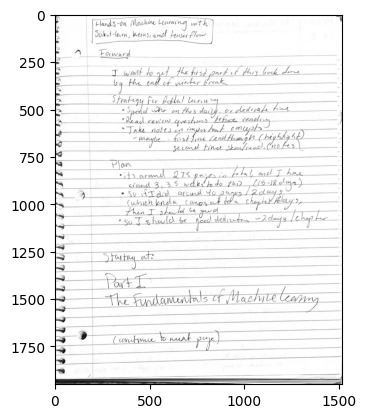

In [42]:
test_image_path = r'C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\images\note-transfer ch1-6_Page_01_Image_0001.jpg'
test_image = cv2.imread(test_image_path)
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY)
plt.imshow(test_image, cmap='gray')

Get our result (which contains the bounding boxes we need)

In [43]:
result = model.predict(test_image_path)


image 1/1 C:\Users\gjbur\Desktop\Code\note-transfer\development\dataset\images\note-transfer ch1-6_Page_01_Image_0001.jpg: 1024x800 None77.7ms
Speed: 13.5ms preprocess, 77.7ms inference, 7.4ms postprocess per image at shape (1, 3, 1024, 800)


In [44]:
for box in result[0].obb.xywhr:
    print(box)

tensor([ 824.3023,  945.6768,  386.6688, 1220.0867,    1.5527], device='cuda:0')
tensor([8.2127e+02, 5.7244e+02, 1.1545e+03, 3.7778e+02, 7.6703e-03], device='cuda:0')
tensor([ 817.2875, 1506.0520,  146.9489, 1248.2174,    1.5600], device='cuda:0')
tensor([6.1273e+02, 1.7146e+03, 6.3765e+02, 1.3993e+02, 1.5371e-02], device='cuda:0')
tensor([5.2153e+02, 8.4183e+01, 7.8814e+02, 1.3886e+02, 1.9718e-02], device='cuda:0')
tensor([ 390.2332, 1299.0880,  129.1441,  262.5409,    1.5601], device='cuda:0')
tensor([8.2739e+02, 3.2087e+02, 1.1010e+03, 1.2405e+02, 1.4331e-02], device='cuda:0')
tensor([538.1173,  97.5413, 321.5099, 544.2606,   0.9020], device='cuda:0')


Now we can use these results (x_center, y_center, width, height, angle) as the crops to our original image. We use opencv to first rotate the original image and crop it.

In [58]:
# Takes image and crop vars, returns cropped image
def crop_from_obb(image, xywhr):
    x_center, y_center, width, height, theta = xywhr.tolist()

    # Transformation for rotation, rotate image
    rotation_matrix = cv2.getRotationMatrix2D((x_center, y_center), np.degrees(theta), 1.0)
    rotated_image = cv2.warpAffine(image, rotation_matrix, (image.shape[1], image.shape[0]))

    # Crop the rotated image
    x_corner, y_corner = int(x_center - width/2), int(y_center - height/2)
    cropped_image = rotated_image[y_corner:y_corner+int(height), x_corner:x_corner+int(width)]

    # Rotate to flat if needed
    if theta > 1: # Might want to change based on height and width or somethign eventually
        cropped_image = cv2.rotate(cropped_image, cv2.ROTATE_90_CLOCKWISE)

    return cropped_image


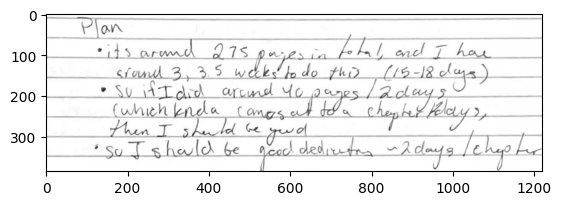

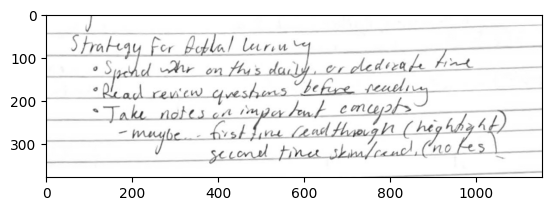

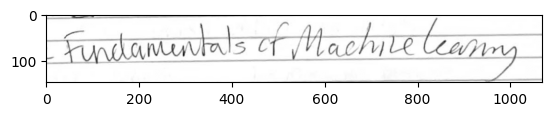

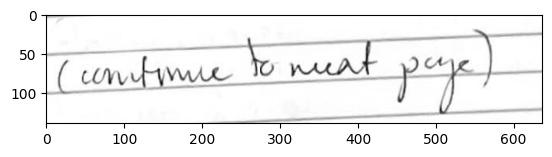

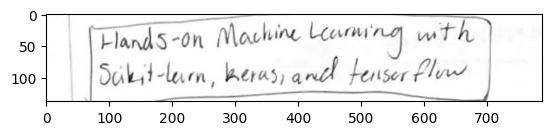

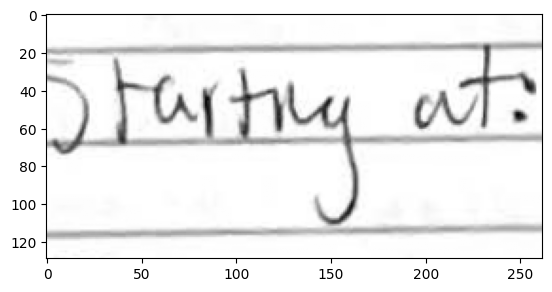

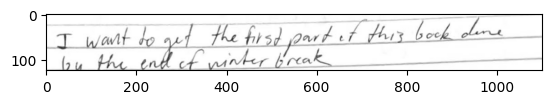

C:\Users\gjbur\AppData\Local\Temp\ipykernel_17380\3008140404.py:3: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(cropped, cmap='gray')


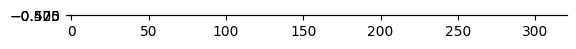

In [59]:
for xywhr in result[0].obb.xywhr:
    cropped = crop_from_obb(test_image, xywhr)
    plt.imshow(cropped, cmap='gray')
    plt.show()
    

Alright so some issues with rotation that we put a quick fix on. But overall it is possible to segment out these bounding boxes. And with better models, we'll be able to segment much better and more generalized.

## Regular Bounding Boxes

These just have their four corners, so you can just chop them with simple matrix slicing.

In [67]:
# Takes image and normal bounding box (no rotation) bounds (top left, bottom right points)
# Returns the cropped image
def crop_from_bb(image, xyxy):
    x1, y1, x2, y2 = xyxy.tolist()
    x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
    return image[y1:y2+1, x1:x2+1]

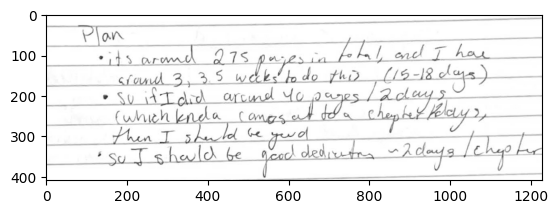

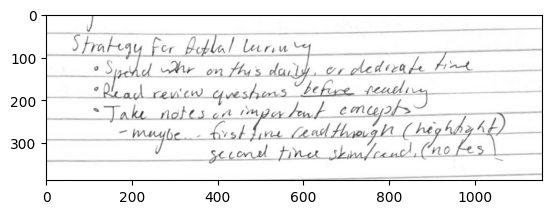

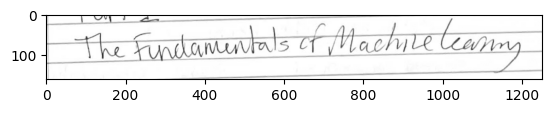

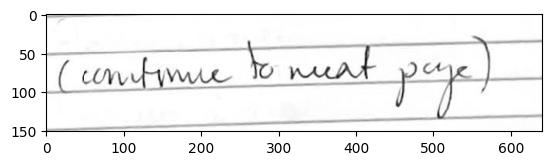

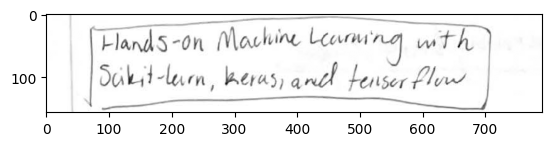

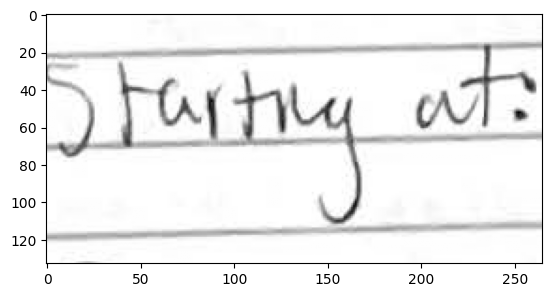

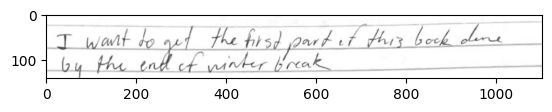

C:\Users\gjbur\AppData\Local\Temp\ipykernel_17380\118592834.py:3: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(cropped, cmap='gray')


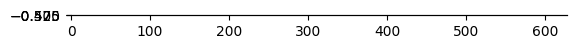

In [68]:
for xyxy in result[0].obb.xyxy:
    cropped = crop_from_bb(test_image, xyxy)
    plt.imshow(cropped, cmap='gray')
    plt.show()

Looks good! Of course, the segmentation models will need a little work.